# CSV_file_Hitters_Multinomial_Classification

### 안타수(Hits)와 홈런수(HmRun)로 급여(Salary)를 상중하로 예측하는 Multinomial Classification을 구현하라
### (Colab을 사용하는 경우 "files/Hitters.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

if tf.__version__ >= '2.17.0':
    from tf_keras import optimizers
else:
    from tensorflow.keras import optimizers

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_03_CSV_file_Hitters_Multinomial_Classification/files/Hitters.csv'
else :
  files_path = '../files/Hitters.csv'

>### < Hitters.csv의 주요 column >
>#### AtBat : 타석수
>#### Hits : 안타수
>#### HmRun : 홈런수
>#### runs : 타점
>#### Warks : 볼넷
>#### Salary : 급여

In [4]:
# Hitters.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


> ### csv 파일 전처리

In [5]:
# 특정 column만 가져오기
df = df.loc[:, ['Hits', 'HmRun', 'Salary']]
df.head()

,Hits,HmRun,Salary
0,66,1,NaN
1,81,7,475.0
2,130,18,480.0
3,141,20,500.0
4,87,10,91.5


In [6]:
# Missing 데이터 제거
df = df.dropna()
df.head()

,Hits,HmRun,Salary
1,81,7,475.0
2,130,18,480.0
3,141,20,500.0
4,87,10,91.5
5,169,4,750.0


In [7]:
# Salary를 상(2), 중(1), 하(0)으로 구분
df.loc[df['Salary'] >= 600, 'Salary2'] = 2
df.loc[(df['Salary'] >= 250) & (df['Salary'] < 600), 'Salary2'] = 1
df.loc[df['Salary'] < 250, 'Salary2'] = 0
df.head()

,Hits,HmRun,Salary,Salary2
1,81,7,475.0,1.0
2,130,18,480.0,1.0
3,141,20,500.0,1.0
4,87,10,91.5,0.0
5,169,4,750.0,2.0


In [8]:
# Salary2가 0인 데이터 개수, 1인 데이터 개수, 2인 데이터 개수를 출력
salary2 = df['Salary2']
print(salary2.value_counts())

Salary2
2.0    97
0.0    87
1.0    79
Name: count, dtype: int64


In [9]:
input = np.array(df[['Hits', 'HmRun']], dtype= np.float32)
target = np.array(df['Salary2'], dtype= np.float32).reshape((-1,1))

In [10]:
print(input.shape)
print(input[:10])
print(target.shape)
print(target[:10])

(263, 2)
[[ 81.   7.]
 [130.  18.]
 [141.  20.]
 [ 87.  10.]
 [169.   4.]
 [ 37.   1.]
 [ 73.   0.]
 [ 81.   6.]
 [ 92.  17.]
 [159.  21.]]
(263, 1)
[[1.]
 [1.]
 [1.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [2.]
 [1.]]


In [11]:
target_onehot = tf.one_hot(target.reshape((-1,)), 3)

x_input = tf.constant(input, dtype=tf.float32)
labels = tf.constant(target_onehot, dtype=tf.float32)

In [12]:
print(x_input.shape)
print(x_input[:10])
print(labels.shape)
print(labels[:10])

(263, 2)
tf.Tensor(
[[ 81.   7.]
 [130.  18.]
 [141.  20.]
 [ 87.  10.]
 [169.   4.]
 [ 37.   1.]
 [ 73.   0.]
 [ 81.   6.]
 [ 92.  17.]
 [159.  21.]], shape=(10, 2), dtype=float32)
(263, 3)
tf.Tensor(
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]], shape=(10, 3), dtype=float32)


In [13]:
# 1. W, B 정의
W = tf.Variable(tf.random.normal((2,3)), dtype=tf.float32)
B = tf.Variable(tf.random.normal((3,)), dtype=tf.float32)

In [14]:
# 2. Min Max Scaler 적용
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

In [15]:
# 3. Hypothesis() 정의
def logits(x):
  return tf.matmul(x, W) + B

def Hypothesis(x):
  return tf.nn.softmax(logits(x))

In [16]:
# 4. Cost() 정의
def Cost():
  return tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=logits(x_input), labels=labels))

In [17]:
# 5. Training

In [18]:
%%time

# Parameter Set
epochs = 20000
learning_rate = 0.05

optimizer = optimizers.SGD(learning_rate=learning_rate)

training_idx = np.arange(0, epochs+1, 1)
cost_graph = np.zeros(epochs+1)

for cnt in range(0, epochs+1):
  cost_graph[cnt] = Cost()
  if cnt % (epochs/20) == 0:
    print("[{:>6}] cost = {:>10.4}".format(cnt, cost_graph[cnt]))

  optimizer.minimize(Cost,[W, B])

[     0] cost =      1.652
[  1000] cost =      1.034
[  2000] cost =      1.005
[  3000] cost =     0.9987
[  4000] cost =     0.9969
[  5000] cost =     0.9963
[  6000] cost =     0.9961
[  7000] cost =      0.996
[  8000] cost =     0.9959
[  9000] cost =     0.9959
[ 10000] cost =     0.9959
[ 11000] cost =     0.9959
[ 12000] cost =     0.9959
[ 13000] cost =     0.9959
[ 14000] cost =     0.9959
[ 15000] cost =     0.9959
[ 16000] cost =     0.9959
[ 17000] cost =     0.9959
[ 18000] cost =     0.9959
[ 19000] cost =     0.9959
[ 20000] cost =     0.9959
CPU times: user 3min 7s, sys: 0 ns, total: 3min 7s
Wall time: 3min 6s


In [19]:
# 6. Hypothesis test (x_input 사용)
H_x = Hypothesis(x_input)

for x,h,l in zip(x_input_org, H_x, labels):
  print("Hits:{},HmRun:{} [label:{}] => Salay:{}: {}".format(x[0],x[1],np.argmax(l), np.argmax(h.numpy()),h))

Hits:81.0,HmRun:7.0 [label:1] => Salay:0: [0.4236469  0.3592162  0.21713686]
Hits:130.0,HmRun:18.0 [label:1] => Salay:2: [0.24407947 0.27053538 0.48538518]
Hits:141.0,HmRun:20.0 [label:1] => Salay:2: [0.20657082 0.24277923 0.55064994]
Hits:87.0,HmRun:10.0 [label:0] => Salay:0: [0.39828706 0.35086894 0.25084388]
Hits:169.0,HmRun:4.0 [label:2] => Salay:2: [0.17710774 0.22551014 0.5973822 ]
Hits:37.0,HmRun:1.0 [label:0] => Salay:0: [0.54295504 0.36657348 0.09047154]
Hits:73.0,HmRun:0.0 [label:0] => Salay:0: [0.46294883 0.36939356 0.16765758]
Hits:81.0,HmRun:6.0 [label:0] => Salay:0: [0.42636156 0.3603361  0.21330236]
Hits:92.0,HmRun:17.0 [label:2] => Salay:0: [0.36274227 0.33479375 0.30246392]
Hits:159.0,HmRun:21.0 [label:1] => Salay:2: [0.157254   0.20190968 0.64083636]
Hits:53.0,HmRun:4.0 [label:1] => Salay:0: [0.50221634 0.3693475  0.12843616]
Hits:113.0,HmRun:13.0 [label:1] => Salay:2: [0.31119275 0.31309468 0.37571257]
Hits:60.0,HmRun:0.0 [label:2] => Salay:0: [0.4946707  0.37115645 

In [20]:
# 7. Hypothesis test의 Accuracy를 계산하여 출력
def Accuracy(y_h, y):
    return np.mean(np.equal(y_h,y).astype(np.float32))
Acc = Accuracy(np.argmax(H_x, axis=1), np.argmax(labels, axis=1))
print(Acc)

0.5171103


In [21]:
# 8. predict (Hits가 171, HmRun이 10일 때 Salay를 0, 1, 2로 예측)
def predict(x):
  return Hypothesis((x-x_min)/(x_max-x_min))
x_test = tf.constant([[171.0, 10.0]], dtype= tf.float32)
H_x = predict(x_test)
print("\n[ Prediction by specific data ]")
print("Hits : {}, HmRun : {} => Salay: {}".format(x_test[0,0],x_test[0,1],np.argmax(H_x[0])),H_x[0].numpy())


[ Prediction by specific data ]
Hits : 171.0, HmRun : 10.0 => Salay: 2 [0.1565322  0.20519911 0.63826865]


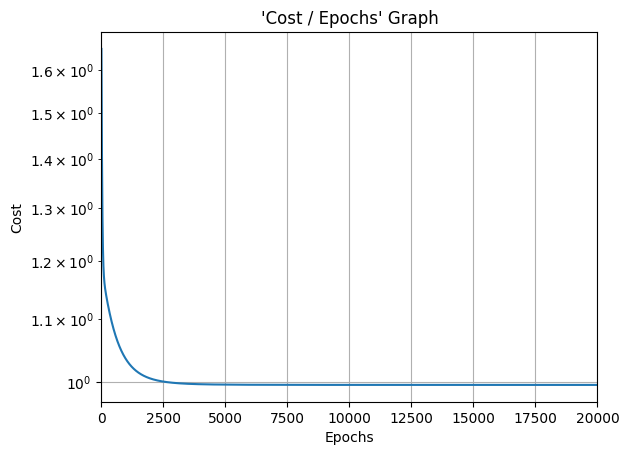

In [22]:
# 9. Training 회수 별 Cost 값을 그래프로 출력
plt.title("'Cost / Epochs' Graph")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.plot(training_idx, cost_graph)
plt.xlim(0, epochs)
plt.grid(True)
plt.semilogy()
plt.show()

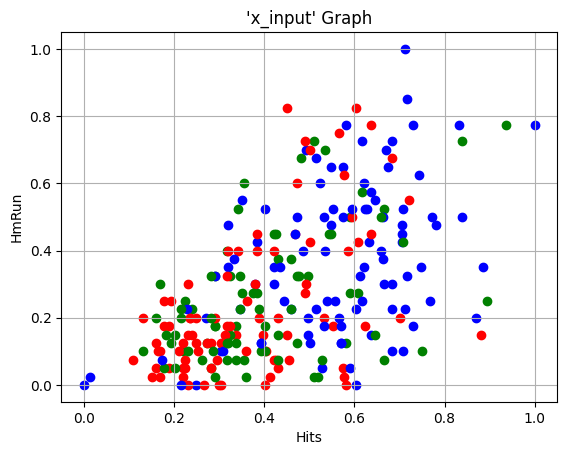

In [23]:
# 10. x_input을 시각화 -> Hits를 x축, HmRun을 y축으로 -> labels에 따라 색깔을 R(0), G(1), B(2) dot로 표시하는 그래프 출력
plt.title("'x_input' Graph")
plt.xlabel("Hits")
plt.ylabel("HmRun")
for i in range(labels.shape[0]):
    if(np.argmax(labels[i]) == 0):
        plt.scatter(x_input[i][0], x_input[i][1], color='red')
    elif(np.argmax(labels[i]) == 1):
        plt.scatter(x_input[i][0], x_input[i][1], color='green')
    else:
        plt.scatter(x_input[i][0], x_input[i][1], color='blue')
plt.grid(True)
plt.show()